In [1]:
import pandas as pd
import sdv
from sdv.datasets.local import load_csvs
from sdv.metadata import Metadata
from sdv.single_table import GaussianCopulaSynthesizer

# Print SDV version
print(sdv.__version__)

# Load the CSV file from the 'data' folder
datasets = load_csvs(
    folder_name='data',  # Specify the correct folder name where the file is located
    read_csv_parameters={
        'skipinitialspace': True,
        'encoding': 'utf-8'  # Changed encoding to UTF-8
    })

# The data is available under the file name 'breach_report'
data = datasets['breach_report']

# Display a sample of the dataset
print(data.head())

# Create metadata from the dataframe
metadata = Metadata.detect_from_dataframe(data=data, table_name='breach_report')

# Step 1: Create the synthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer on the data
synthesizer.fit(data)

# Sample synthetic data
synthetic_data = synthesizer.sample(num_rows=1_000_000)  # You can change the number of rows as needed

# Save synthetic data to CSV
synthetic_data.to_csv('synthetic_data.csv', index=False)

# Load real data from CSV
real_data = pd.read_csv('data/breach_report.csv')

# Load synthetic data from CSV
synthetic_data = pd.read_csv('synthetic_data.csv')

# Drop the 'covered_entity_type' column from both datasets
real_data = real_data.drop(columns=['covered_entity_type'])
synthetic_data = synthetic_data.drop(columns=['covered_entity_type'])

# Display a sample of the synthetic data
print(synthetic_data.head())


1.19.0
          name_of_covered_entity state  covered_entity_type  \
0          iTrust Wellness Group    SC  Healthcare Provider   
1                  Madera County    CA          Health Plan   
2    PCC Pediatric EHR Solutions    VT   Business Associate   
3             Premera Blue Cross    WA          Health Plan   
4  Redwood Coast Regional Center    CA  Healthcare Provider   

   individuals_affected breach_submission_date  \
0                   981              8/10/2023   
1                  1146               8/9/2023   
2                   520               8/9/2023   
3                 33212               8/8/2023   
4                  1345               8/7/2023   

                   type_of_breach location_of_breached_information  \
0             Hacking/IT Incident                            Email   
1  Unauthorized Access/Disclosure                            Email   
2  Unauthorized Access/Disclosure                            Email   
3             Hacking/IT Incident

/home/pradyumnakubear/anaconda3/envs/first_python_env/lib/python3.9/site-packages/sdv/datasets/local.py:36: UserWarning: Ignoring incompatible files ['HidingSensitiveData.png', 'to_gpt.ipynb'] in folder 'data'.
  warnings.warn(f"Ignoring incompatible files {other_files} in folder '{folder_name}'.")
/home/pradyumnakubear/anaconda3/envs/first_python_env/lib/python3.9/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


  name_of_covered_entity           state  individuals_affected  \
0          sdv-pii-8qst0        New York                 54795   
1          sdv-pii-vtj89  North Carolina                  1274   
2          sdv-pii-w7aog          Oregon                 17923   
3          sdv-pii-4vyyx    Pennsylvania                  1173   
4          sdv-pii-nw1d7            Iowa                  1678   

  breach_submission_date                  type_of_breach  \
0             11/13/2022             Hacking/IT Incident   
1             09/21/2022             Hacking/IT Incident   
2             04/17/2022             Hacking/IT Incident   
3             01/12/2022             Hacking/IT Incident   
4             05/15/2023  Unauthorized Access/Disclosure   

  location_of_breached_information business_associate_present  web_description  
0                            Email                        Yes              NaN  
1                   Network Server                         No              NaN  

In [4]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic_report = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata)

Generating report ...

(1/2) Evaluating Data Validity: |█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 53.75it/s]|
Data Validity Score: 100.0%



/home/pradyumnakubear/anaconda3/envs/first_python_env/lib/python3.9/site-packages/sdmetrics/single_column/statistical/boundary_adherence.py:58: RuntimeWarning: invalid value encountered in scalar divide
  return valid.sum() / len(synthetic_data)


(2/2) Evaluating Data Structure: |███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 512.63it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [5]:
! pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 18.6 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 16.3 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 14.5 MB/s eta 0:00:0031m15.1 MB/s eta 0:00:01


In [6]:
!pip install matplotlib

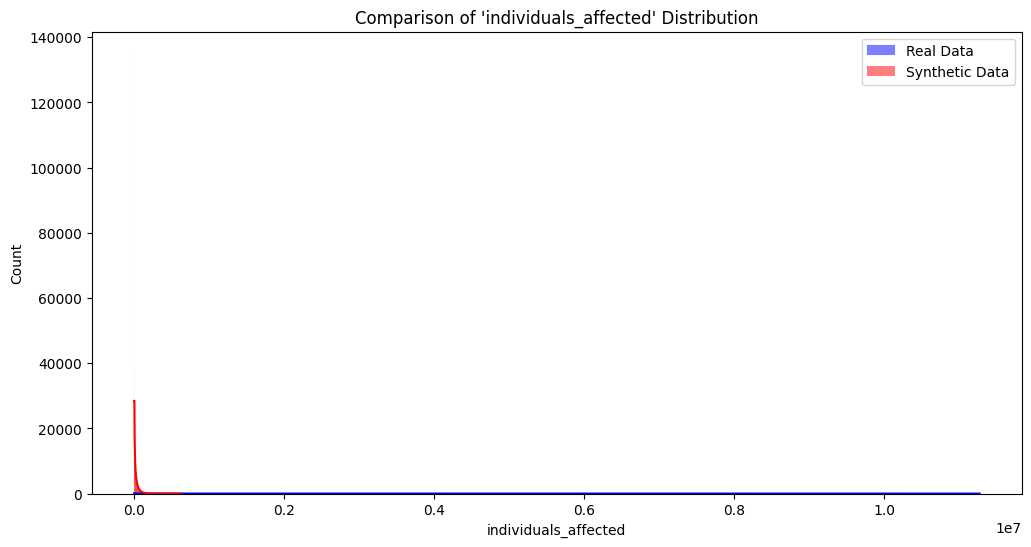

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual comparison of distributions for numerical columns
plt.figure(figsize=(12, 6))
sns.histplot(real_data['individuals_affected'], color='blue', label='Real Data', kde=True)
sns.histplot(synthetic_data['individuals_affected'], color='red', label='Synthetic Data', kde=True)
plt.legend()
plt.title("Comparison of 'individuals_affected' Distribution")
plt.show()
